In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('real_estate_cleaned.csv')
df.head()

,price,status,area,rate_per_sqft,property_type,locality,builder_name,rera_approval,bhk_count,society,company_name,flat_type
0,10700000.0,under construction,1138,9450.0,2 bhk apartment in m3m antalya hills phase i,sector 79,home,True,2.0,m3m antalya hills phase i,m3m,apartment
1,14400000.0,under construction,1528,9450.0,3 bhk apartment in m3m antalya hills phase i,sector 79,property in gurgaon,True,3.0,m3m antalya hills phase i,m3m,apartment
2,10700000.0,under construction,1138,9450.0,2 bhk apartment in m3m antalya hills phase i,sector 79,properties for sale in gurgaon,True,2.0,m3m antalya hills phase i,m3m,apartment
3,40000000.0,ready to move,4500,8888.0,4 bhk independent floor,sector 57,mm india pvt ltd,False,4.0,outside socity,outside,plot
4,24000000.0,under construction,1800,13333.0,3 bhk independent floor in anant raj estate plots,sector 63,mm india pvt ltd,True,3.0,anant raj estate plots,anant,floor


In [4]:
df.shape

(14223, 12)

In [5]:
df.isnull().sum()

price            0
status           0
area             0
rate_per_sqft    0
property_type    0
locality         0
builder_name     0
rera_approval    0
bhk_count        0
society          0
company_name     0
flat_type        0
dtype: int64

In [6]:
df.columns.tolist()

['price',
 'status',
 'area',
 'rate_per_sqft',
 'property_type',
 'locality',
 'builder_name',
 'rera_approval',
 'bhk_count',
 'society',
 'company_name',
 'flat_type']

In [7]:
X = df[
    [
        'area',
        'bhk_count',
        'rera_approval',
        'status',
        'flat_type'
    ]
].copy()

y = df['price'].copy()

X.shape, y.shape

((14223, 5), (14223,))

In [8]:
X['rera_approval'] = X['rera_approval'].astype(int)

In [10]:
X['rera_approval'].value_counts()

rera_approval
0    8774
1    5449
Name: count, dtype: int64

In [11]:
numerical_features = [
    'area',
    'bhk_count',
    'rera_approval'
]

categorical_features = [
    'status',
    'flat_type'
]

In [12]:
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train.shape, X_test.shape

((11378, 5), (2845, 5))

In [14]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [15]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

pd.Series({
    'MAE': linear_mae,
    'MSE': linear_mse,
    'RMSE': linear_rmse,
    'R2': linear_r2
}).round(4)

MAE     2.615722e+07
MSE     3.544198e+15
RMSE    5.953317e+07
R2      6.930000e-02
dtype: float64

In [16]:
cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

pd.Series({
    'Mean CV R2': cv_scores.mean(),
    'CV Std': cv_scores.std()
}).round(4)

Mean CV R2   -16.6724
CV Std        33.4495
dtype: float64

In [17]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

In [18]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

pd.Series({
    'MAE': rf_mae,
    'MSE': rf_mse,
    'RMSE': rf_rmse,
    'R2': rf_r2
}).round(4)

MAE     1.153254e+07
MSE     1.147574e+15
RMSE    3.387586e+07
R2      6.986000e-01
dtype: float64

In [19]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

pd.Series({
    'Mean CV R2': rf_cv_scores.mean(),
    'CV Std': rf_cv_scores.std()
}).round(4)

Mean CV R2    0.5706
CV Std        0.1439
dtype: float64

In [20]:
gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_predictions = gradient_boosting_model.predict(X_test)

In [21]:
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_predictions)

pd.Series({
    'MAE': gb_mae,
    'MSE': gb_mse,
    'RMSE': gb_rmse,
    'R2': gb_r2
}).round(4)

MAE     1.498308e+07
MSE     1.325344e+15
RMSE    3.640527e+07
R2      6.520000e-01
dtype: float64

In [22]:
gb_cv_scores = cross_val_score(
    gradient_boosting_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

pd.Series({
    'Mean CV R2': gb_cv_scores.mean(),
    'CV Std': gb_cv_scores.std()
}).round(4)

Mean CV R2    0.5093
CV Std        0.1421
dtype: float64

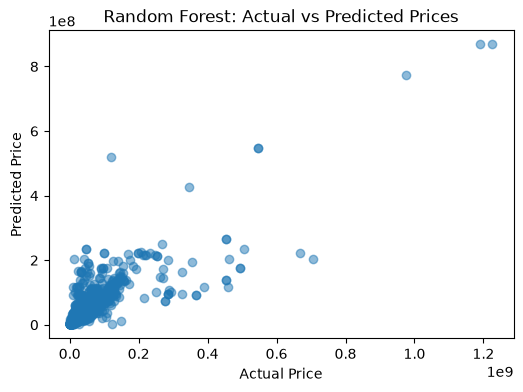

In [24]:
plt.figure(figsize=(6, 4))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Prices')

plt.show()

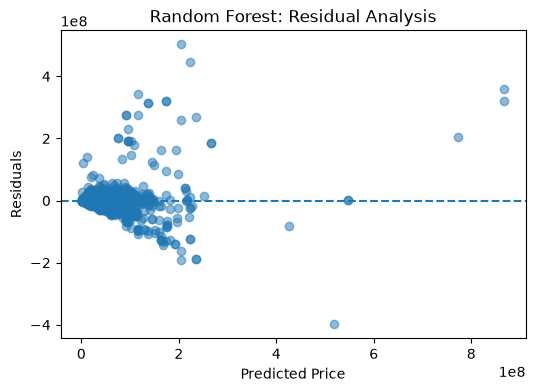

In [26]:
residuals = y_test - rf_predictions

plt.figure(figsize=(6, 4))

plt.scatter(
    rf_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Random Forest: Residual Analysis')

plt.show()

In [27]:
feature_names = random_forest_model.named_steps['preprocessor'].get_feature_names_out()

feature_importance = random_forest_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(
    'Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,num__area,0.863113
1,num__bhk_count,0.066226
2,num__rera_approval,0.012282
3,cat__status_ready to move,0.011376
9,cat__flat_type_plot,0.009921
8,cat__flat_type_penthouse,0.007024
6,cat__flat_type_floor,0.006580
5,cat__status_under construction,0.006476
7,cat__flat_type_house,0.006341
4,cat__status_resale,0.006053


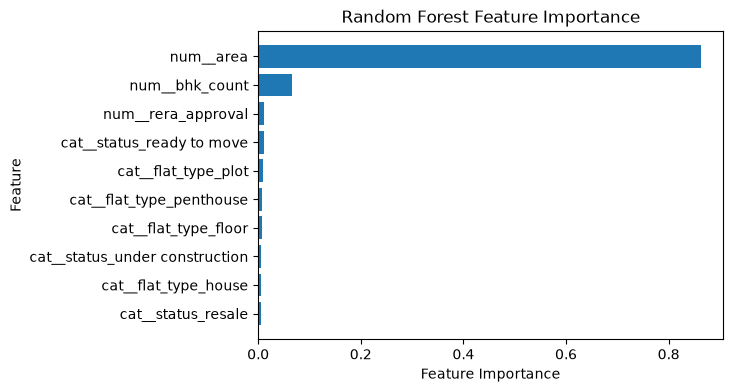

In [29]:
plt.figure(figsize=(6, 4))

plt.barh(
    importance_df['Feature'].head(10)[::-1],
    importance_df['Importance'].head(10)[::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.show()

In [30]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    'R2 (%)': [
        linear_r2 * 100,
        rf_r2 * 100,
        gb_r2 * 100
    ],
    'Mean CV R2 (%)': [
        cv_scores.mean() * 100,
        rf_cv_scores.mean() * 100,
        gb_cv_scores.mean() * 100
    ]
})

model_comparison.round(2)

,Model,MAE,RMSE,R2 (%),Mean CV R2 (%)
0,Linear Regression,26157218.16,59533165.64,6.93,-1667.24
1,Random Forest,11532540.78,33875860.34,69.86,57.06
2,Gradient Boosting,14983084.75,36405272.39,65.20,50.93


In [31]:
prediction_results = X_test.copy()

prediction_results['Actual Price'] = y_test.values
prediction_results['Predicted Price'] = rf_predictions
prediction_results['Residual'] = y_test.values - rf_predictions

prediction_results.head()

,area,bhk_count,rera_approval,status,flat_type,Actual Price,Predicted Price,Residual
7887,1531,4.0,1,under construction,apartment,15300000.0,2.213499e+07,-6.834992e+06
8216,1785,3.0,0,ready to move,apartment,12200000.0,1.532084e+07,-3.120837e+06
13947,1920,3.0,0,ready to move,apartment,11500000.0,1.342879e+07,-1.928795e+06
8141,2150,3.0,1,under construction,apartment,14200000.0,4.278783e+07,-2.858783e+07
13396,2404,3.0,0,ready to move,apartment,25900000.0,3.136929e+07,-5.469294e+06


In [32]:
prediction_results.to_csv(
    'real_estate_regression_results.csv',
    index=False
)

In [33]:
pd.Series({
    'Test R2 (%)': rf_r2 * 100,
    'Mean CV R2 (%)': rf_cv_scores.mean() * 100,
    'MAE': rf_mae,
    'RMSE': rf_rmse,
    'Test Samples': len(y_test)
}).round(2)

Test R2 (%)             69.86
Mean CV R2 (%)          57.06
MAE               11532540.78
RMSE              33875860.34
Test Samples          2845.00
dtype: float64